# 📈 Visualisation et Exploration des Données (EDA)
Ce notebook explore les datasets pour isoler les facteurs influençant les **rendements agricoles**.
L'objectif final est de prédire le rendement (target), nous allons donc vérifier quelques hypothèses :
1. Le rendement a-t-il augmenté au fil du temps (technologie, etc.) ?
2. Quel est l'impact du climat (températures et précipitations) ?
3. L'utilisation de pesticides et d'engrais montre-t-elle une forte relation avec le rendement ?


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')
DIR = 'data/cleaned'


## 1. Chargement et préparation des données

In [43]:
# Chargement de la cible : Rendement (Cultures végétales)
df_cultures = pd.read_csv(f'{DIR}/production_cultures.csv')
df_cultures.columns = ['Element' if ('l' in col.lower() and 'm' in col.lower() and 'nt' in col.lower()) else 'Unite' if 'unit' in col.lower() else col for col in df_cultures.columns]
df_rendement = df_cultures[df_cultures['Element'] == 'Rendement'].copy()
df_rendement = df_rendement.rename(columns={'Valeur': 'Rendement_kg_ha'})
df_rendement = df_rendement[df_rendement['Rendement_kg_ha'] <= 100000]

# Température
df_temp = pd.read_csv(f'{DIR}/mean_temperature.csv')
df_temp = df_temp.rename(columns={'Valeur': 'Temperature_C'})

# Précipitations
df_precip = pd.read_csv(f'{DIR}/precipitations.csv')
df_precip = df_precip.rename(columns={'Valeur': 'Precipitations_mm'})

# Pesticides (Agrégation par pays/année)
df_pest = pd.read_csv(f'{DIR}/pesticides.csv')
df_pest_agg = df_pest.groupby(['Pays', 'Annee'])['Valeur'].sum().reset_index()
df_pest_agg = df_pest_agg.rename(columns={'Valeur': 'Pesticides_kg_ha'})

# Engrais (Fertilizers)
df_fert = pd.read_csv(f'{DIR}/fertilizers_nutrient.csv')
df_fert_agg = df_fert.groupby(['Pays', 'Annee'])['Valeur'].sum().reset_index()
df_fert_agg = df_fert_agg.rename(columns={'Valeur': 'Engrais_kg_ha'})
print("Datasets source chargés avec succès.")

Datasets source chargés avec succès.


## 2. Aperçu des Distributions et Classements

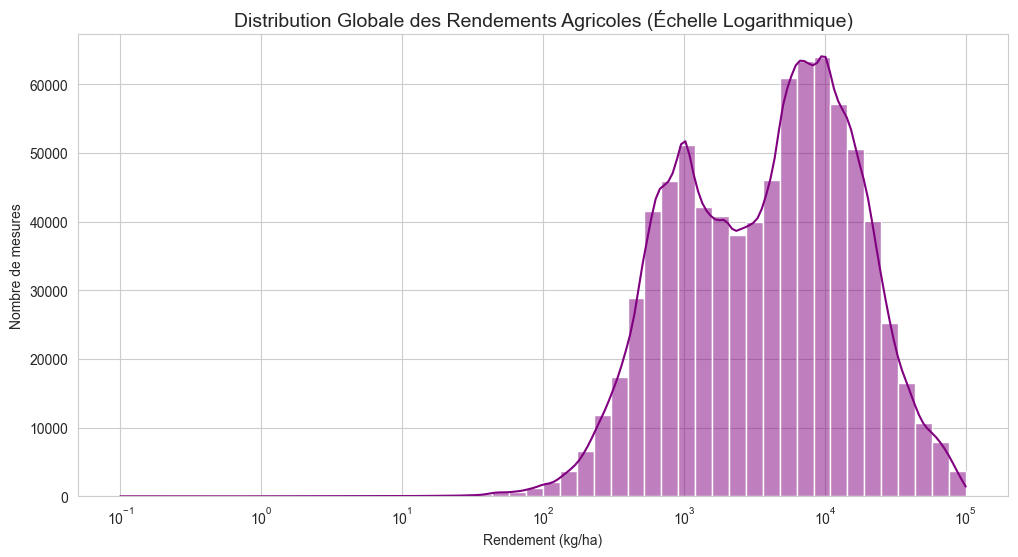

In [44]:
plt.figure(figsize=(12, 6))
df_pos = df_rendement[df_rendement['Rendement_kg_ha'] > 0]
sns.histplot(data=df_pos, x='Rendement_kg_ha', bins=50, log_scale=True, kde=True, color='purple')
plt.title('Distribution Globale des Rendements Agricoles (Échelle Logarithmique)', fontsize=14)
plt.xlabel('Rendement (kg/ha)')
plt.ylabel('Nombre de mesures')
plt.show()


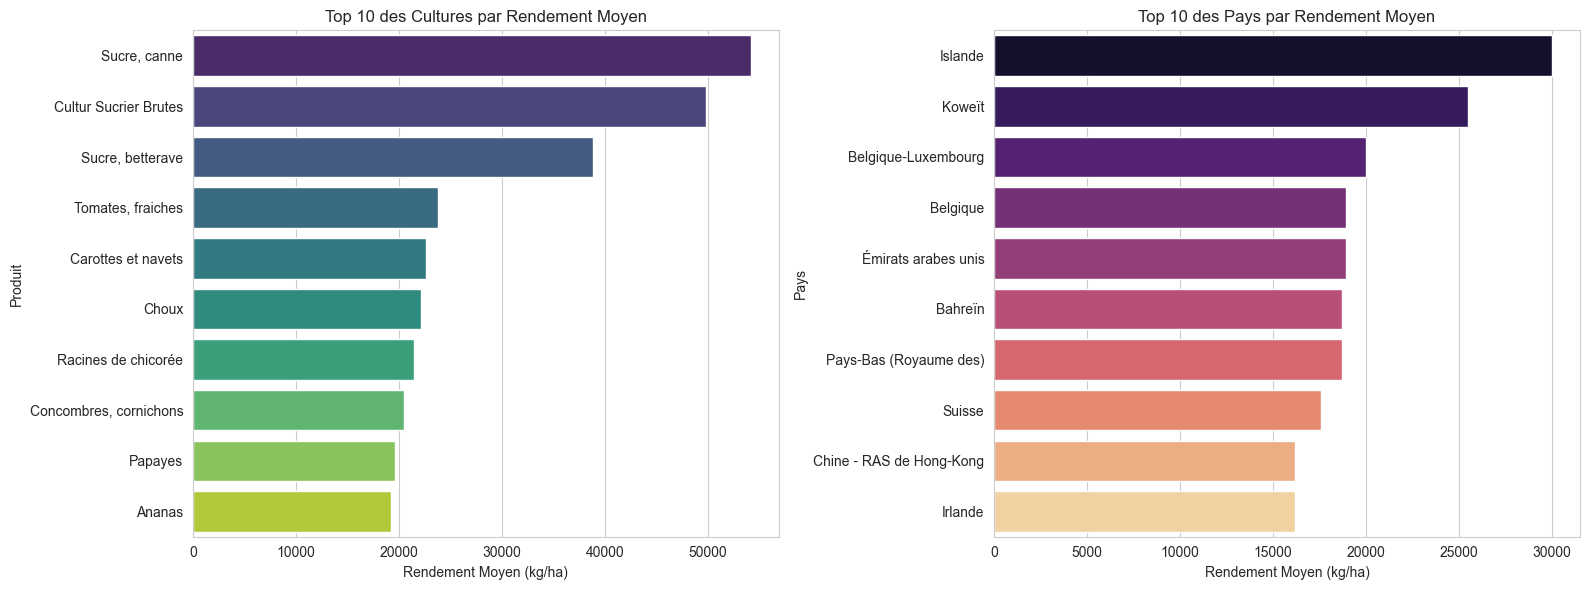

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_crops = df_rendement.groupby('Produit')['Rendement_kg_ha'].mean().nlargest(10)
sns.barplot(x=top_crops.values, y=top_crops.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 des Cultures par Rendement Moyen')
axes[0].set_xlabel('Rendement Moyen (kg/ha)')

top_countries = df_rendement.groupby('Pays')['Rendement_kg_ha'].mean().nlargest(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 des Pays par Rendement Moyen')
axes[1].set_xlabel('Rendement Moyen (kg/ha)')

plt.tight_layout()
plt.show()


### 🔄 Fusion des données pour les Graphiques de relation

In [46]:
# On calcule le rendement moyen global par pays/année
df_rend_agg = df_rendement.groupby(['Pays', 'Annee'])['Rendement_kg_ha'].mean().reset_index()

# Jointures
df_merged = df_rend_agg.merge(df_temp[['Pays', 'Annee', 'Temperature_C']], on=['Pays', 'Annee'], how='inner')
df_merged = df_merged.merge(df_precip[['Pays', 'Annee', 'Precipitations_mm']], on=['Pays', 'Annee'], how='inner')
df_merged = df_merged.merge(df_pest_agg, on=['Pays', 'Annee'], how='left')
df_merged = df_merged.merge(df_fert_agg, on=['Pays', 'Annee'], how='left')

display(df_merged.head())
print(f"Taille du dataset fusionné : {df_merged.shape}")


,Pays,Annee,Rendement_kg_ha,Temperature_C,Precipitations_mm,Pesticides_kg_ha,Engrais_kg_ha
0,Afghanistan,1961,4702.146341,11.35,377.88,NaN,0.14
1,Afghanistan,1962,4881.224390,11.12,300.84,NaN,0.14
2,Afghanistan,1963,4867.185366,12.38,343.42,NaN,0.14
3,Afghanistan,1964,4917.770732,10.38,384.51,NaN,0.14
4,Afghanistan,1965,5273.995122,11.21,390.93,NaN,0.14


Taille du dataset fusionné : (3536, 7)


## 3. Évolution Globale des Rendements au fil du temps


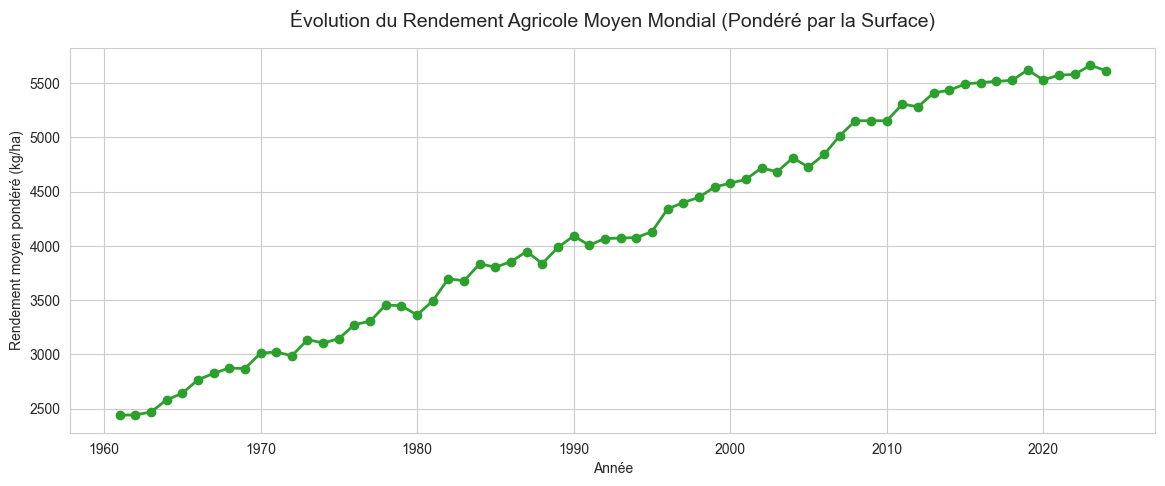

In [47]:
# Extraction de la superficie récoltée pour pondérer les rendements
df_superficie = df_cultures[df_cultures['Element'].str.contains('Superficie', na=False)].copy()
df_superficie = df_superficie.rename(columns={'Valeur': 'Superficie_ha'})

# Jointure entre le rendement et la superficie
df_rend_weight = pd.merge(df_rendement, df_superficie[['Pays', 'Produit', 'Annee', 'Superficie_ha']], on=['Pays', 'Produit', 'Annee'], how='inner')

# Calcul du rendement global pondéré : Somme(Rendement * Superficie) / Somme(Superficie)
df_rend_weight['Prod_Rend_Sup'] = df_rend_weight['Rendement_kg_ha'] * df_rend_weight['Superficie_ha']
grouped = df_rend_weight.groupby('Annee')
trend_yearly = grouped['Prod_Rend_Sup'].sum() / grouped['Superficie_ha'].sum()

plt.figure(figsize=(14, 5))
plt.plot(trend_yearly.index, trend_yearly.values, marker='o', color='#2ca02c', linewidth=2)
plt.title('Évolution du Rendement Agricole Moyen Mondial (Pondéré par la Surface)', fontsize=14, pad=15)
plt.xlabel('Année')
plt.ylabel('Rendement moyen pondéré (kg/ha)')
plt.show()


## 4. Impact du Climat sur le Rendement (Température & Précipitations)


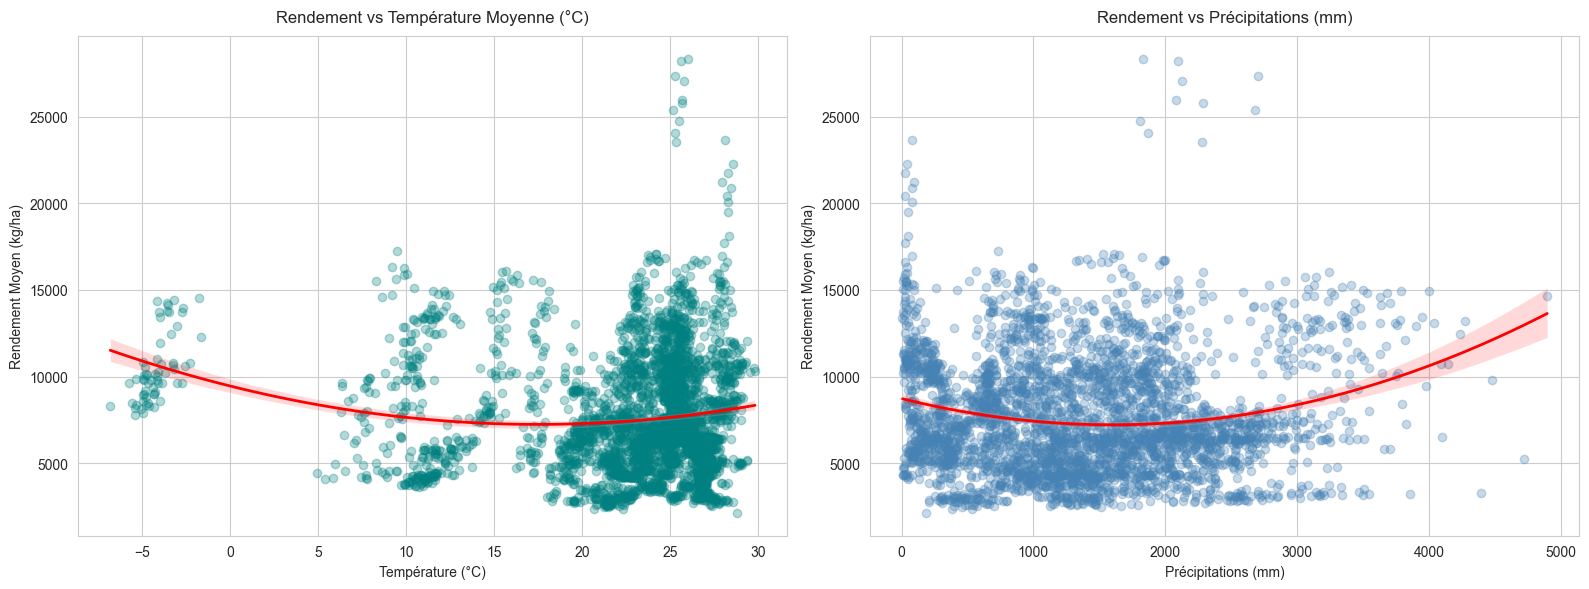

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ajout de order=2 pour la courbe de la température
sns.regplot(data=df_merged, x='Temperature_C', y='Rendement_kg_ha', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red', 'linewidth': 2}, 
            order=2, # <-- LA CORRECTION EST ICI
            ax=axes[0])
axes[0].set_title('Rendement vs Température Moyenne (°C)', pad=10)
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('Rendement Moyen (kg/ha)')

# Ajout de order=2 pour la courbe des précipitations
sns.regplot(data=df_merged, x='Precipitations_mm', y='Rendement_kg_ha', 
            scatter_kws={'alpha':0.3, 'color':'steelblue'}, 
            line_kws={'color':'red', 'linewidth': 2}, 
            order=2, # <-- LA CORRECTION EST ICI
            ax=axes[1])
axes[1].set_title('Rendement vs Précipitations (mm)', pad=10)
axes[1].set_xlabel('Précipitations (mm)')
axes[1].set_ylabel('Rendement Moyen (kg/ha)')

plt.tight_layout()
plt.show()

## 5. Impact des Intrants : Pesticides & Engrais


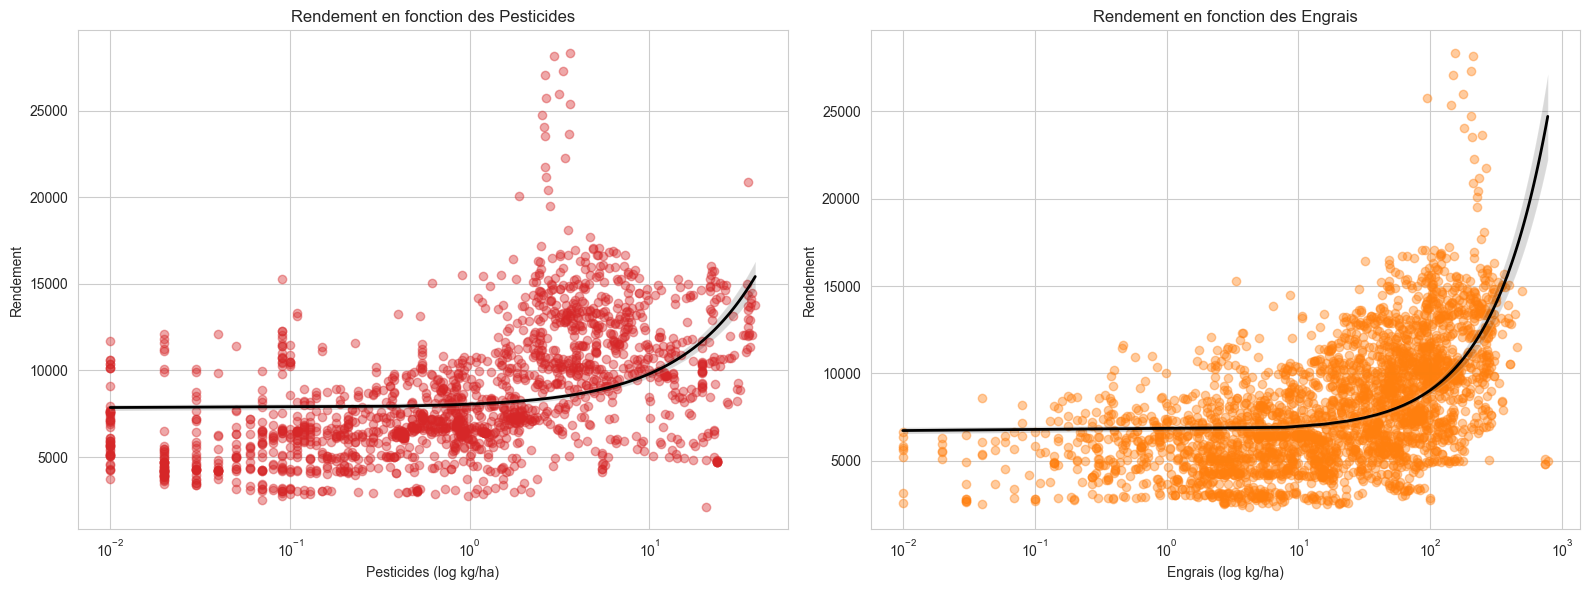

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df_merged[df_merged['Pesticides_kg_ha'] > 0], 
            x='Pesticides_kg_ha', y='Rendement_kg_ha', 
            scatter_kws={'alpha':0.4, 'color':'#d62728'}, line_kws={'color':'black', 'linewidth': 2}, ax=axes[0])
axes[0].set_title('Rendement en fonction des Pesticides')
axes[0].set_xscale('log')
axes[0].set_xlabel('Pesticides (log kg/ha)')
axes[0].set_ylabel('Rendement')

sns.regplot(data=df_merged[df_merged['Engrais_kg_ha'] > 0], 
            x='Engrais_kg_ha', y='Rendement_kg_ha', 
            scatter_kws={'alpha':0.4, 'color':'#ff7f0e'}, line_kws={'color':'black', 'linewidth': 2}, ax=axes[1])
axes[1].set_title('Rendement en fonction des Engrais')
axes[1].set_xscale('log')
axes[1].set_xlabel('Engrais (log kg/ha)')
axes[1].set_ylabel('Rendement')

plt.tight_layout()
plt.show()


## 6. Analyse Multivariée Globale (Pairplot & Matrice)


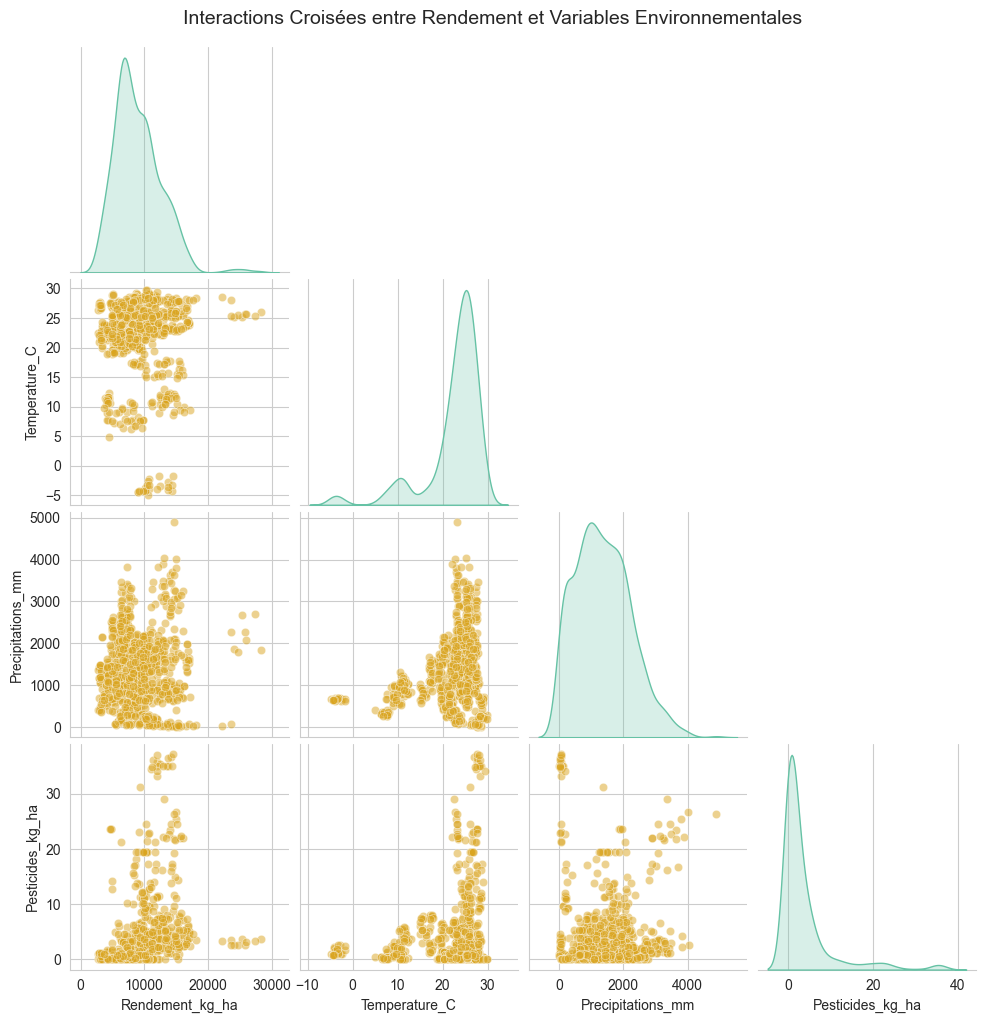

In [50]:
# Un Pairplot permet de voir toutes les intéractions d'un coup (on prend un sample pour la rapidité)
sample_df = df_merged.dropna().sample(n=min(1000, len(df_merged.dropna())), random_state=42)
sns.pairplot(sample_df[['Rendement_kg_ha', 'Temperature_C', 'Precipitations_mm', 'Pesticides_kg_ha']], 
             diag_kind='kde', corner=True, plot_kws={'alpha': 0.5, 'color': 'goldenrod'})
plt.suptitle('Interactions Croisées entre Rendement et Variables Environnementales', y=1.02, fontsize=14)
plt.show()


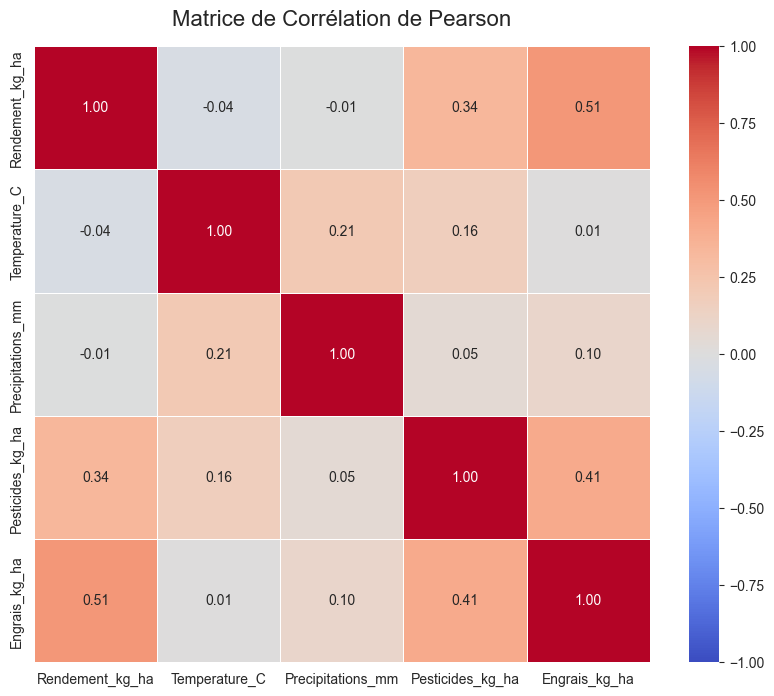

In [51]:
plt.figure(figsize=(10, 8))
corr_cols = ['Rendement_kg_ha', 'Temperature_C', 'Precipitations_mm', 'Pesticides_kg_ha', 'Engrais_kg_ha']
corr_matrix = df_merged[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5, fmt='.2f')
plt.title('Matrice de Corrélation de Pearson', fontsize=16, pad=15)
plt.show()


### ✍️ Conclusions pour le Machine Learning

1. **Distributions variées** : Le rendement est très asymétrique selon les pays et les récoltes.
2. **Le paradoxe du climat** : Le climat a beaucoup de variance. Un modèle purement linéaire sera médiocre. Il faudra privilégier des modèles à arbres décisionnels (Random Forest, XGBoost) car un surplus de température ou de pluie est destructeur ! 
3. **L'importance pivot des intrants** : Engrais et Pesticides ont généralement la corrélation positive la plus constante avec le taux de Rendement.
4. **Série temporelle** : La composante « Année » capte la tendance à la hausse technologique globale.

**L'étape suivante consiste à concevoir le pipeline d'entraînement !**